# Vendedor

In [1]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importação de Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression
# from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
# from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')
# # Importação do dataset
df = pd.read_csv('data/crop_yield.csv')
df.head(5)

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
features = ['Soil_Type_Clay',
            'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy',
            'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Rainfall_mm', 'Temperature_Celsius',
            'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny']

In [6]:
scaler = MinMaxScaler()
scaler = StandardScaler()

df['Days_to_Harvest'] = scaler.fit_transform(df[['Days_to_Harvest']])

df['Yield_tons_per_hectare'] = scaler.fit_transform(df[['Yield_tons_per_hectare']])
df['Temperature_Celsius'] = scaler.fit_transform(df[['Temperature_Celsius']])
df['Rainfall_mm'] = scaler.fit_transform(df[['Rainfall_mm']])

# Uplicando o One-Hot Encoding  na coluna Crop
df_encoded = pd.get_dummies(df, columns=['Crop'], drop_first=True)
df_Crop = df_encoded.copy()

df_Region = pd.get_dummies(df_Crop, columns=['Region'], drop_first=True)

df_Type = pd.get_dummies(df_Region, columns=['Soil_Type'], drop_first=True)

df_Encoding = pd.get_dummies(df_Type, columns=['Weather_Condition'], drop_first=True)

In [7]:
df_Encoding.head()

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Yield_tons_per_hectare,Crop_Cotton,Crop_Maize,Crop_Rice,Crop_Soybean,...,Region_North,Region_South,Region_West,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt,Weather_Condition_Rainy,Weather_Condition_Sunny
0,1.335747,0.023821,False,True,0.674477,1.123645,True,False,False,False,...,False,False,True,False,False,False,True,False,False,False
1,1.703634,-1.312747,True,True,1.368028,2.285709,False,False,True,False,...,False,True,False,True,False,False,False,False,True,False
2,-1.546977,0.317020,False,False,0.057988,-2.075968,False,False,False,False,...,True,False,False,False,True,False,False,False,False,True
3,1.681287,-1.504137,False,True,1.599212,1.101103,False,False,False,True,...,True,False,False,False,False,False,True,False,True,False
4,0.694233,0.569997,True,True,0.212110,1.531783,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [8]:
df_Encoding.shape

(1000000, 21)

In [9]:
df_Encoding.columns

Index(['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used',
       'Irrigation_Used', 'Days_to_Harvest', 'Yield_tons_per_hectare',
       'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat',
       'Region_North', 'Region_South', 'Region_West', 'Soil_Type_Clay',
       'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy',
       'Soil_Type_Silt', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny'],
      dtype='object')

In [10]:
# Importação do dataset
financ = pd.read_csv('data/tabela_resumo_10000_linhas.csv')
financ.head(3)

,data_emissao,RFR_QTD,RFR_VLT,CSF_QTD,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_QTD,...,RR_OP_QTD,RR_OP_DISC,RR_OP_SJ,CC_A_PAGAR,CC_DIV_NAO_PAGAS,CC_PREJUIZO,CC_LIMITE,PC_DATA,PC_DESC,PC_QTD_TOT
0,29-09-2025 19:24:36,2,"R$ 14.205.918,65",-,-,6,"R$ 420.522,97",8,"R$ 4.169.681,61",-,...,45,NADA CONSTA,NADA CONSTA,"R$ 101.671,62","R$ 5.057,96","R$ 7.231,70","R$ 43.521,87",13/08/2024,EMPRÉSTIMO PESSOAL,3
1,29-09-2025 19:24:36,6,"R$ 1.001.021,05",-,-,8,"R$ 106.067,00",8,"R$ 4.182.318,45",-,...,24,NADA CONSTA,NADA CONSTA,"R$ 130.889,12","R$ 8.273,26","R$ 151.813,01","R$ 9.446,58",19/05/2024,RENOVAÇÃO DE CADASTRO,6
2,29-09-2025 19:24:36,21,"R$ 7.647.272,95",-,-,14,"R$ 80.695,97",5,"R$ 2.826.612,37",-,...,46,NADA CONSTA,NADA CONSTA,"R$ 50.770,74","R$ 8.432,02","R$ 266.152,70","R$ 138.464,95",09/05/2024,SOLICITACAO DE CRÉDITO,2


In [11]:
# 1. Lista das colunas que contêm dados monetários (R$)
colunas_monetarias = [
    'RFR_VLT', 'CSF_VLT', 'TPN_VLT', 'RJF_VLT', 'LC_VLT',
    'RI_VALOR', 'PN_VALOR', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
    'CC_PREJUIZO', 'CC_LIMITE'
]

for coluna in colunas_monetarias:
    financ[coluna] = financ[coluna].replace('-', np.nan)

    financ[coluna] = (financ[coluna].astype(str)
                                    .str.replace('R$', '', regex=False)
                                    .str.replace('.', '', regex=False)
                                    .str.replace(',', '.', regex=False)
                                    .str.strip())

    financ[coluna] = pd.to_numeric(financ[coluna], errors='coerce')

In [12]:
# 1. Lista das colunas que já foram limpas e convertidas para float
colunas_para_imputar = [
    'RFR_VLT', 'CSF_VLT', 'TPN_VLT', 'RJF_VLT', 'LC_VLT',
    'RI_VALOR', 'PN_VALOR', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
    'CC_PREJUIZO', 'CC_LIMITE'
]

for coluna in colunas_para_imputar:
    media_coluna = financ[coluna].mean()

    financ[coluna].fillna(media_coluna, inplace=True)

    media_formatada = f"{media_coluna:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

/tmp/ipykernel_9168/68013594.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  financ[coluna].fillna(media_coluna, inplace=True)


In [13]:
colunas_data = ['RI_DATA', 'PN_DATA', 'RR_INICIO', 'PC_DATA']

for col in colunas_data:
    financ[col] = pd.to_datetime(financ[col], format='%d/%m/%Y', errors='coerce')


hoje = pd.to_datetime('29/09/2025', format='%d/%m/%Y')
financ['IDADE_RELACIONAMENTO_DIAS'] = (hoje - financ['RR_INICIO']).dt.days

In [14]:
mapeamento_risco = {
    'A+': 1, 'A': 2, 'B+': 3, 'B': 4, 'B-': 5, 'C': 6,
    'D': 7, 'E': 8, 'F': 9, 'G': 10, '-': 11
}
financ['CRC_NUMERICA'] = financ['CRC_QTD'].map(mapeamento_risco)


financ = pd.get_dummies(financ, columns=['CSFB_STATUS'], prefix='STATUS')

In [15]:
# Remove os últimos 4 ou mais dígitos (o código) da coluna RI_INFORM
financ['RI_INFORM_LIMPO'] = financ['RI_INFORM'].str.replace(r'\d+$', '', regex=True).str.strip()

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

colunas_numericas = financ.select_dtypes(include=[np.number]).columns.tolist()
financ[colunas_numericas] = scaler.fit_transform(financ[colunas_numericas])

In [17]:
excluir_colunas = ['data_emissao', 'CSF_QTD', 'LC_QTD', 'RI_INFORM', 'PN_DATA', 'RR_INICIO', 'RR_OP_DISC', 'RR_OP_SJ', 'PC_DATA', 'PC_DESC', 'RI_DATA', 'RI_INFORM_LIMPO', 'CRC_QTD', 'CRC_VLT']
financ = financ.drop(columns=excluir_colunas)
financ.head(3)

,RFR_QTD,RFR_VLT,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_VLT,RI_QTD_TOT,RI_VALOR,...,CC_PREJUIZO,CC_LIMITE,PC_QTD_TOT,IDADE_RELACIONAMENTO_DIAS,CRC_NUMERICA,STATUS_-,STATUS_APROVADO,STATUS_CONSULTA,STATUS_NEGADO,STATUS_PENDENTE
0,0.066667,0.568100,0.492451,0.400000,0.419333,0.8,0.411060,0.060458,0.421053,0.849497,...,0.007513,0.142175,0.222222,0.707162,0.888889,False,True,False,False,False
1,0.200000,0.039627,0.492451,0.533333,0.104188,0.8,0.412337,0.072266,0.421053,0.575192,...,0.497650,0.028198,0.555556,0.342971,0.555556,False,False,False,False,True
2,0.700000,0.305616,0.492451,0.933333,0.078761,0.5,0.275363,0.164609,0.578947,0.534820,...,0.885266,0.459748,0.111111,0.272414,0.555556,False,False,False,True,False


In [18]:
financ.shape

(10000, 25)

In [19]:
# Armazena o número de linhas ANTES de deletar
num_linhas_antes = financ.shape[0]

financ.drop_duplicates(inplace=True)

num_linhas_depois = financ.shape[0]

linhas_deletadas = num_linhas_antes - num_linhas_depois

In [20]:
# Criar a coluna ID para a tabela de dados financ
financ['ID'] = range(1, len(financ) + 1)

# Criar a coluna ID para a tabela de dados
df_Encoding['ID'] = range(1, len(df_Encoding) + 1)

In [21]:
# criar o dataset final
df_final = pd.merge(financ, df_Encoding, on='ID', how='inner')

In [22]:
df_final.shape

(10000, 47)

In [23]:
# deletar coluna ID do df_final
df_final = df_final.drop(columns=['ID'])

In [24]:
features = ['RFR_QTD', 'RFR_VLT', 'CSF_VLT', 'TPN_QTD', 'TPN_VLT', 'RJF_QTD',
       'RJF_VLT', 'LC_VLT', 'RI_QTD_TOT', 'RI_VALOR', 'PN_VALOR',
       'RR_INST_QTD', 'RR_OP_QTD', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
       'CC_PREJUIZO', 'CC_LIMITE', 'PC_QTD_TOT', 'IDADE_RELACIONAMENTO_DIAS',
       'CRC_NUMERICA', 'STATUS_-', 'STATUS_APROVADO', 'STATUS_CONSULTA',
       'STATUS_NEGADO', 'STATUS_PENDENTE', 'Soil_Type_Clay', 'Soil_Type_Loam',
       'Soil_Type_Peaty', 'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Cotton',
       'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat', 'Rainfall_mm',
       'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used',
       'Days_to_Harvest', 'Weather_Condition_Rainy', 'Weather_Condition_Sunny'
       ]
df_Encoding = df_final[features]

X = df_Encoding[features]

In [25]:
# --- 1. SELEÇÃO DE FEATURES E DEFINIÇÃO DOS PESOS AHP SIMULADOS ---

# 1.1 Lista de todas as colunas do seu dataset que serão usadas no Score.
colunas_score = [
    'RFR_QTD', 'RFR_VLT', 'CSF_VLT', 'TPN_QTD', 'TPN_VLT', 'RJF_QTD',
    'RJF_VLT', 'LC_VLT', 'RI_QTD_TOT', 'RI_VALOR', 'PN_VALOR',
    'RR_INST_QTD', 'RR_OP_QTD', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
    'CC_PREJUIZO', 'CC_LIMITE', 'PC_QTD_TOT', 'IDADE_RELACIONAMENTO_DIAS',
    'CRC_NUMERICA', 'STATUS_-', 'STATUS_APROVADO', 'STATUS_CONSULTA',
    'STATUS_NEGADO', 'STATUS_PENDENTE',
    # Colunas Geológicas/Cultivo (assumindo que já estão numéricas/codificadas)
    'Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty', 'Soil_Type_Sandy',
    'Soil_Type_Silt', 'Crop_Cotton', 'Crop_Maize', 'Crop_Rice', 'Crop_Soybean',
    'Crop_Wheat', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used',
    'Irrigation_Used', 'Days_to_Harvest', 'Weather_Condition_Rainy',
    'Weather_Condition_Sunny'
]

# 1.2 Definição dos Pesos AHP (Fase 2).
# ESTES SÃO PESOS DE EXEMPLO! Você DEVE substituí-los pelos pesos reais
# calculados na sua matriz de comparação AHP.
# NOTA: A soma total dos pesos deve ser 1.0.

pesos_ahp = {
    # Risco Financeiro Principal (Maior Impacto)
    'CRC_NUMERICA': 0.15,
    'RI_VALOR': 0.10,

    # Risco Financeiro Secundário
    'RFR_VLT': 0.05, 'CSF_VLT': 0.05, 'TPN_VLT': 0.03, 'RJF_VLT': 0.03,
    'LC_VLT': 0.02, 'PN_VALOR': 0.02,

    # Histórico e Relacionamento
    'RR_INST_QTD': 0.04, 'RR_OP_QTD': 0.02, 'IDADE_RELACIONAMENTO_DIAS': 0.03,

    # Dívidas e Limites
    'CC_A_PAGAR': 0.05, 'CC_DIV_NAO_PAGAS': 0.05, 'CC_PREJUIZO': 0.05,
    'CC_LIMITE': 0.03,

    # Quantitativos Simples (Menor Impacto)
    'RFR_QTD': 0.01, 'TPN_QTD': 0.01, 'RJF_QTD': 0.01, 'RI_QTD_TOT': 0.01,
    'PC_QTD_TOT': 0.01,

    # Status (Colunas Dummies)
    'STATUS_APROVADO': 0.01, 'STATUS_NEGADO': 0.03, 'STATUS_CONSULTA': 0.01,
    'STATUS_-': 0.005, 'STATUS_PENDENTE': 0.005,

    # Risco de Cultivo/Geológico (Pesos de Exemplo)
    'Rainfall_mm': 0.05, 'Temperature_Celsius': 0.02, 'Days_to_Harvest': 0.02,
    'Soil_Type_Clay': 0.01, 'Soil_Type_Loam': 0.01, 'Soil_Type_Peaty': 0.01,
    'Soil_Type_Sandy': 0.01, 'Soil_Type_Silt': 0.01,
    'Crop_Cotton': 0.005, 'Crop_Maize': 0.005, 'Crop_Rice': 0.005,
    'Crop_Soybean': 0.005, 'Crop_Wheat': 0.005,
    'Fertilizer_Used': 0.01, 'Irrigation_Used': 0.01,
    'Weather_Condition_Rainy': 0.01, 'Weather_Condition_Sunny': 0.01
}

# 1.3 Converte os pesos para uma série de Pandas para garantir a ordenação correta
pesos_serie = pd.Series(pesos_ahp)

# 2.0 Filtra o DataFrame para usar apenas as colunas com pesos definidos
# Isso também serve como um check para garantir que todas as colunas existem no df_Encoding
X_score = df_Encoding[colunas_score]

# 2.1 Reordenar os pesos para coincidir com a ordem das colunas no DataFrame de treino
pesos_ordenados = pesos_serie.reindex(X_score.columns)

# --- 3. CÁLCULO DO SCORE FINAL (Fórmula AHP) ---

# 3.1 Aplica a fórmula de Soma Ponderada (S_j = SUM(V_i,j * W_i))
# A multiplicação matricial (.dot) calcula o score bruto para cada linha.
df_Encoding['SCORE_AHP_BRUTO'] = X_score.dot(pesos_ordenados)

print("\nCálculo do Score AHP Bruto Concluído.")
print(f"Soma dos pesos usados: {round(pesos_ordenados.sum(), 2)}")


# --- 4. NORMALIZAÇÃO FINAL PARA ESCALA 0-100 (Melhor Interpretação) ---

# 4.1 Calcula os valores mínimo e máximo do score bruto
min_score = df_Encoding['SCORE_AHP_BRUTO'].min()
max_score = df_Encoding['SCORE_AHP_BRUTO'].max()

# 4.2 Normaliza para a escala 0 a 100
# Um score de 100 representa o perfil de 'confiabilidade' mais próximo do ideal ponderado.
df_Encoding['SCORE_FINAL_CONFIABILIDADE'] = (
    (df_Encoding['SCORE_AHP_BRUTO'] - min_score) / (max_score - min_score) * 100
)



Cálculo do Score AHP Bruto Concluído.
Soma dos pesos usados: 1.04


/tmp/ipykernel_9168/3537268388.py:72: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Encoding['SCORE_AHP_BRUTO'] = X_score.dot(pesos_ordenados)
/tmp/ipykernel_9168/3537268388.py:86: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Encoding['SCORE_FINAL_CONFIABILIDADE'] = (


Plotar gráfico


*   Verificar dados dupolicados.
*   Apagar os dados duplicados.



In [26]:
def grup(data):
  if data <= 25:
    return 1
  elif (data > 25 and data <= 50):
    return 2
  elif (data > 50 and data <= 75):
    return 3
  elif (data > 75 and data <= 100):
    return 4
  else:
      return None

In [27]:
df_Encoding['Score'] = df_Encoding['SCORE_FINAL_CONFIABILIDADE'].apply(grup)
df_Encoding.head(3)

/tmp/ipykernel_9168/983355315.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Encoding['Score'] = df_Encoding['SCORE_FINAL_CONFIABILIDADE'].apply(grup)


,RFR_QTD,RFR_VLT,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_VLT,RI_QTD_TOT,RI_VALOR,...,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Weather_Condition_Rainy,Weather_Condition_Sunny,SCORE_AHP_BRUTO,SCORE_FINAL_CONFIABILIDADE,Score
0,0.066667,0.568100,0.492451,0.400000,0.419333,0.8,0.411060,0.060458,0.421053,0.849497,...,1.335747,0.023821,False,True,0.674477,False,False,0.560436,71.201274,3
1,0.200000,0.039627,0.492451,0.533333,0.104188,0.8,0.412337,0.072266,0.421053,0.575192,...,1.703634,-1.312747,True,True,1.368028,True,False,0.480894,58.151561,3
2,0.700000,0.305616,0.492451,0.933333,0.078761,0.5,0.275363,0.164609,0.578947,0.534820,...,-1.546977,0.317020,False,False,0.057988,False,True,0.34589,36.002791,2


In [28]:
# df_Encoding recebe o df_Encoding menos as colunas SCORE_FINAL_CONFIABILIDADE e SCORE_AHP_BRUTO
df_Encoding = df_Encoding.drop(columns=['SCORE_FINAL_CONFIABILIDADE', 'SCORE_AHP_BRUTO'])

In [29]:
df_Encoding.head(20)

,RFR_QTD,RFR_VLT,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_VLT,RI_QTD_TOT,RI_VALOR,...,Crop_Soybean,Crop_Wheat,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Weather_Condition_Rainy,Weather_Condition_Sunny,Score
0,0.066667,0.568100,0.492451,0.400000,0.419333,0.8,0.411060,0.060458,0.421053,0.849497,...,False,False,1.335747,0.023821,False,True,0.674477,False,False,3
1,0.200000,0.039627,0.492451,0.533333,0.104188,0.8,0.412337,0.072266,0.421053,0.575192,...,False,False,1.703634,-1.312747,True,True,1.368028,True,False,3
2,0.700000,0.305616,0.492451,0.933333,0.078761,0.5,0.275363,0.164609,0.578947,0.534820,...,False,False,-1.546977,0.317020,False,False,0.057988,False,True,2
3,0.466667,0.059941,0.094614,0.066667,0.336630,0.5,0.966195,0.486843,0.000000,0.907969,...,True,False,1.681287,-1.504137,False,True,1.599212,True,False,3
4,0.633333,0.340664,0.449212,0.333333,0.712299,1.0,0.373469,0.130171,0.684211,0.027228,...,False,True,0.694233,0.569997,True,True,0.212110,False,False,2
5,0.333333,0.280674,0.492451,0.400000,0.837592,1.0,0.219156,0.888566,0.842105,0.022998,...,True,False,0.952427,1.412625,False,True,-1.174992,True,False,3
6,0.600000,0.081230,0.492451,0.400000,0.465017,1.0,0.863282,0.249166,0.684211,0.075515,...,False,True,-0.739191,0.566222,False,False,-0.558502,True,False,1
7,0.633333,0.629179,0.492451,0.733333,0.479065,1.0,0.623209,0.179720,0.526316,0.437166,...,False,False,-0.418896,0.468402,True,True,-1.675889,False,True,2
8,1.000000,0.093493,0.492451,0.933333,0.118974,0.8,0.601864,0.067511,0.000000,0.768214,...,False,True,-1.417712,-0.104179,True,False,0.867130,False,True,2
9,0.233333,0.954638,0.492451,0.400000,0.488618,0.0,0.501019,0.203118,0.526316,0.256197,...,False,True,-0.596237,-1.365366,False,True,1.368028,True,False,2


In [30]:
df_Encoding.shape

(10000, 43)

In [31]:
df_Encoding.Score.value_counts()

Score
2    4623
3    4471
1     474
4     432
Name: count, dtype: int64

/tmp/ipykernel_9168/2515629879.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


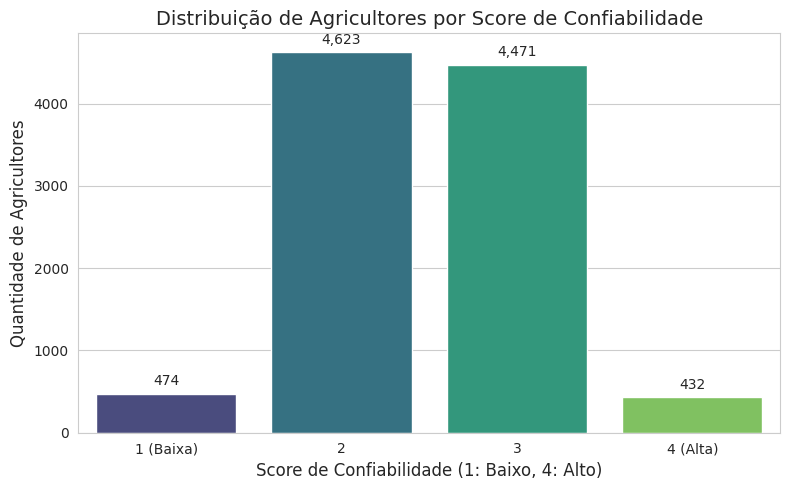

In [32]:
# 1. Obter os dados de contagem (o resultado do seu value_counts())
contagem_scores = df_Encoding['Score'].value_counts().sort_index()

# 2. Configurações para o gráfico
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 3. Criar o gráfico de barras
ax = sns.barplot(
    x=contagem_scores.index,  # Nomes das barras (1, 2, 3, 4)
    y=contagem_scores.values, # Altura das barras (Contagem de Agricultores)
    palette="viridis"
)

# 4. Adicionar rótulos de dados (o número exato de agricultores em cima de cada barra)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)

# 5. Adicionar títulos e rótulos
plt.title('Distribuição de Agricultores por Score de Confiabilidade', fontsize=14)
plt.xlabel('Score de Confiabilidade (1: Baixo, 4: Alto)', fontsize=12)
plt.ylabel('Quantidade de Agricultores', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['1 (Baixa)', '2', '3', '4 (Alta)'])
plt.tight_layout() # Ajusta o layout para evitar cortes
plt.show()

In [33]:
!pip install imbalanced-learn

In [34]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
import pandas as pd

# 1. Separar features e target
X = df_Encoding.drop(columns=["Score"])
y = df_Encoding["Score"]

# 2. Split treino/teste mantendo desbalanceamento real no teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. Escolher o método de oversampling
# opção A → SMOTE (mais comum e estável)
# oversampler = SMOTE(sampling_strategy={1: 2000, 4: 2000}, random_state=42)

# opção B → ADASYN (mais focado em exemplos difíceis)
oversampler = ADASYN(sampling_strategy={1: 3510, 4: 3510}, random_state=42)

# 4. Aplicar oversampling apenas no treino
X_train_res, y_train_res = oversampler.fit_resample(X_train, y_train)

# 5. Reconstruir DataFrame balanceado de treino (opcional)
df_train_balanced = pd.concat(
    [pd.DataFrame(X_train_res, columns=X_train.columns),
     pd.DataFrame(y_train_res, columns=["Score"])],
    axis=1
)

# 6. Ver nova distribuição
print("Distribuição no treino antes:\n", y_train.value_counts())
print("\nDistribuição no treino depois:\n", y_train_res.value_counts())


Distribuição no treino antes:
 Score
2    3698
3    3577
1     379
4     346
Name: count, dtype: int64

Distribuição no treino depois:
 Score
2    3698
3    3577
1    3491
4    3481
Name: count, dtype: int64


/tmp/ipykernel_9168/3497766011.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


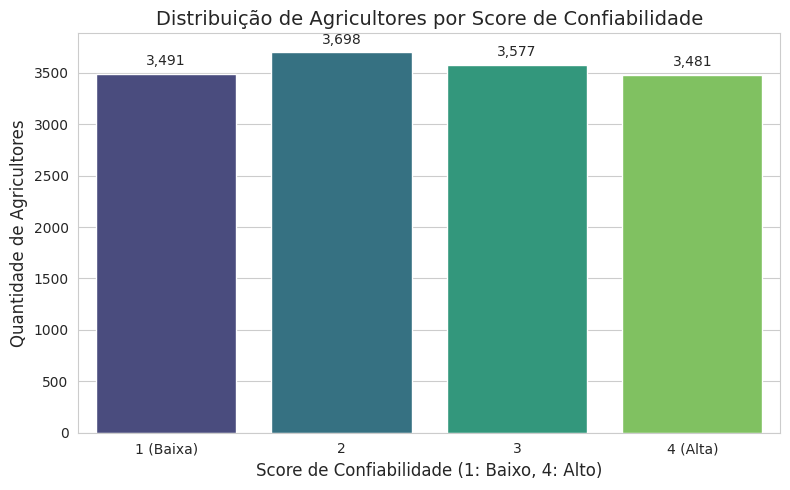

In [35]:
# 1. Obter os dados de contagem (o resultado do seu value_counts())
contagem_scores = df_train_balanced['Score'].value_counts().sort_index()

# 2. Configurações para o gráfico
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# 3. Criar o gráfico de barras
ax = sns.barplot(
    x=contagem_scores.index,  # Nomes das barras (1, 2, 3, 4)
    y=contagem_scores.values, # Altura das barras (Contagem de Agricultores)
    palette="viridis"
)

# 4. Adicionar rótulos de dados (o número exato de agricultores em cima de cada barra)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10)

# 5. Adicionar títulos e rótulos
plt.title('Distribuição de Agricultores por Score de Confiabilidade', fontsize=14)
plt.xlabel('Score de Confiabilidade (1: Baixo, 4: Alto)', fontsize=12)
plt.ylabel('Quantidade de Agricultores', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['1 (Baixa)', '2', '3', '4 (Alta)'])
plt.tight_layout() # Ajusta o layout para evitar cortes
plt.show()

In [36]:
df_classfy = df_train_balanced.copy()
df_class = df_train_balanced.copy()

In [37]:
# 1. Valuation – Avaliação do patrimônio e valor da operação agrícola
valuation = [
    'Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest',
    'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition_Rainy',
    'Weather_Condition_Sunny', 'RI_VALOR'
]

# 2. Due Diligence – Registros ambientais, solo e conformidade
due_diligence = [
    'Soil_Type_Clay', 'Soil_Type_Loam', 'Soil_Type_Peaty',
    'Soil_Type_Sandy', 'Soil_Type_Silt', 'Crop_Cotton',
    'Crop_Maize', 'Crop_Rice', 'Crop_Soybean', 'Crop_Wheat'
]

# 3. Histórico de Contratos – Desempenho e relacionamento
historico_contratos = [
    'RR_INST_QTD', 'RR_OP_QTD', 'IDADE_RELACIONAMENTO_DIAS'
]

# 4. Financeiro – Análise de crédito e rating KSI
financeiro = [
    'CRC_NUMERICA', 'RFR_VLT', 'CSF_VLT', 'TPN_VLT', 'RJF_VLT',
    'LC_VLT', 'PN_VALOR', 'CC_A_PAGAR', 'CC_DIV_NAO_PAGAS',
    'CC_PREJUIZO', 'CC_LIMITE', 'RFR_QTD', 'TPN_QTD', 'RJF_QTD',
    'RI_QTD_TOT', 'PC_QTD_TOT', 'STATUS_APROVADO', 'STATUS_NEGADO',
    'STATUS_CONSULTA', 'STATUS_-', 'STATUS_PENDENTE'
]

# 5. Rastreabilidade – Dados de origem e sustentabilidade
# (Categoria aguardando novas variáveis como CAR, Coordenadas, etc.)
rastreabilidade = []

# Exemplo de como acessar:
categorias = {
    "Valuation": valuation,
    "Due Diligence": due_diligence,
    "Histórico": historico_contratos,
    "Financeiro": financeiro,
    "Rastreabilidade": rastreabilidade
}

In [38]:
df_classfy['mean_valuation'] = df_classfy[valuation].mean(axis=1).astype(float)
df_classfy['mean_due_diligence'] = df_classfy[due_diligence].mean(axis=1).astype(float)
df_classfy['mean_historico_contratos'] = df_classfy[historico_contratos].mean(axis=1).astype(float)
df_classfy['mean_financeiro'] = df_classfy[financeiro].mean(axis=1).astype(float)

# Ensure 'mean_rastreabilidade' column is created and is of float type, even if all NaNs
# This handles the case where rastreabilidade list is empty, resulting in an empty Series mean
if not rastreabilidade:
    df_classfy['mean_rastreabilidade'] = pd.Series([np.nan] * len(df_classfy), index=df_classfy.index, dtype=float)
else:
    df_classfy['mean_rastreabilidade'] = df_classfy[rastreabilidade].mean(axis=1).astype(float)

colunas_medias = ['mean_valuation', 'mean_due_diligence', 'mean_historico_contratos', 'mean_financeiro', 'mean_rastreabilidade']

In [39]:
X.head(5)

,RFR_QTD,RFR_VLT,CSF_VLT,TPN_QTD,TPN_VLT,RJF_QTD,RJF_VLT,LC_VLT,RI_QTD_TOT,RI_VALOR,...,Crop_Rice,Crop_Soybean,Crop_Wheat,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Days_to_Harvest,Weather_Condition_Rainy,Weather_Condition_Sunny
0,0.066667,0.568100,0.492451,0.400000,0.419333,0.8,0.411060,0.060458,0.421053,0.849497,...,False,False,False,1.335747,0.023821,False,True,0.674477,False,False
1,0.200000,0.039627,0.492451,0.533333,0.104188,0.8,0.412337,0.072266,0.421053,0.575192,...,True,False,False,1.703634,-1.312747,True,True,1.368028,True,False
2,0.700000,0.305616,0.492451,0.933333,0.078761,0.5,0.275363,0.164609,0.578947,0.534820,...,False,False,False,-1.546977,0.317020,False,False,0.057988,False,True
3,0.466667,0.059941,0.094614,0.066667,0.336630,0.5,0.966195,0.486843,0.000000,0.907969,...,False,True,False,1.681287,-1.504137,False,True,1.599212,True,False
4,0.633333,0.340664,0.449212,0.333333,0.712299,1.0,0.373469,0.130171,0.684211,0.027228,...,False,False,True,0.694233,0.569997,True,True,0.212110,False,False


In [40]:
# Agora defina o X novamente (sem o Score)
# df_media = df_classfy[colunas_medias]
# X = df_classfy.drop(columns=['Score'])
# X = df_media.copy()

In [41]:


# === 1. Features (X) e Target (y) ===
X = df_classfy.drop(columns=['Score'])
y = df_class['Score']

# === 2. Separar treino e teste com estratificação ===
# 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Conferindo os tamanhos
print("Tamanho conjunto de treino :", X_train.shape, y_train.shape)
print("Tamanho conjunto de teste  :", X_test.shape,  y_test.shape)

# Distribuição das classes para checar estratificação
print("\nDistribuição classes - treino:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição classes - teste:")
print(y_test.value_counts(normalize=True))


Tamanho conjunto de treino : (9972, 47) (9972,)
Tamanho conjunto de teste  : (4275, 47) (4275,)

Distribuição classes - treino:
Score
2    0.259527
3    0.251103
1    0.244986
4    0.244384
Name: proportion, dtype: float64

Distribuição classes - teste:
Score
2    0.259649
3    0.250994
1    0.245146
4    0.244211
Name: proportion, dtype: float64


In [42]:
# Verificando se há valores nulos
print("Valores nulos em X_train:", X_train.isnull().sum().sum())
print("Valores nulos em X_test:", X_test.isnull().sum().sum())

# Verificando tipos de dados
print("\nTipos de dados em X_train:")
print(X_train.dtypes.value_counts())

Valores nulos em X_train: 9972
Valores nulos em X_test: 4275

Tipos de dados em X_train:
float64    28
bool       19
Name: count, dtype: int64


In [43]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score
# Importar Random forest
from sklearn.ensemble import RandomForestClassifier

# Criar e treinar o modelo
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [44]:
# Fazer previsões
y_pred = model.predict(X_test)

In [45]:
# Avaliar os resultados com as métricas
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2%}")
print("\n Relatório de classificação:")
print(classification_report(y_test, y_pred))

Acurácia: 83.06%

 Relatório de classificação:
              precision    recall  f1-score   support

           1       0.91      0.92      0.92      1048
           2       0.72      0.75      0.74      1110
           3       0.76      0.70      0.73      1073
           4       0.93      0.96      0.94      1044

    accuracy                           0.83      4275
   macro avg       0.83      0.83      0.83      4275
weighted avg       0.83      0.83      0.83      4275



In [46]:
# Criar e treinar o modelo
model_RF = RandomForestClassifier(random_state=42)
model_RF.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
# Fazer previsões
y_pred_RF = model_RF.predict(X_test)

In [48]:
# Avaliar os resultados do RandomForest
print(f"Acurácia: {accuracy_score(y_test, y_pred_RF):.2%}")
print("\n Relatório de classificação:")
print(classification_report(y_test, y_pred_RF))

Acurácia: 93.33%

 Relatório de classificação:
              precision    recall  f1-score   support

           1       0.99      0.99      0.99      1048
           2       0.89      0.89      0.89      1110
           3       0.88      0.88      0.88      1073
           4       0.99      0.98      0.98      1044

    accuracy                           0.93      4275
   macro avg       0.93      0.93      0.93      4275
weighted avg       0.93      0.93      0.93      4275



In [49]:
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

In [50]:
# Papiline de Pré-processamento
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer

num_papiline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_papiline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
    ('num', num_papiline, num_cols),
    ('cat', cat_papiline, cat_cols)
])

In [51]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [52]:
# Ajustar os dados de treino
preprocessor.fit_transform(X_train)

# Transformar Treino e teste em matrizes numéricas
X_train_tr = preprocessor.transform(X_train)
X_test_tr = preprocessor.transform(X_test)

/home/vungel/Downloads/M2/Score/.venv/lib/python3.13/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['mean_rastreabilidade']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/vungel/Downloads/M2/Score/.venv/lib/python3.13/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['mean_rastreabilidade']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/vungel/Downloads/M2/Score/.venv/lib/python3.13/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['mean_rastreabilidade']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [53]:
X_train_tr.shape, X_test_tr.shape

((9972, 27), (4275, 27))

In [54]:
from sklearn.feature_selection import SelectKBest
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#importar mutual_info_classif
from sklearn.feature_selection import mutual_info_classif
# importar RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

In [55]:
# Número de Features a serem selecionadas
linear = 8

# Aplicar SelectBest
selector = SelectKBest(score_func=mutual_info_classif, k=linear)

# Gerar X_train e X_test com selector
X_train_selected = selector.fit_transform(X_train_tr, y_train)
X_test_selected = selector.transform(X_test_tr)

In [56]:
# ============================================
# Recuperação dos nomes das features
# ============================================

# Get feature names after preprocessing, including handling of skipped columns
# and one-hot encoding. This is the most robust way to get the final feature names
# from a ColumnTransformer.
all_features = preprocessor.get_feature_names_out()

# If you specifically need `num_features` and `cat_features` lists separately,
# you would typically parse `all_features` based on the transformer prefixes (e.g., 'num__', 'cat__').
# Example (if needed later):
# num_features = [f for f in all_features if f.startswith('num__')]
# cat_features = [f for f in all_features if f.startswith('cat__')]

# ============================================
# Máscara das features selecionadas
# ============================================

mask = selector.get_support()

# ============================================
# Lista final das k features selecionadas
# ============================================

selected_features = all_features[mask]

print("==== MELHORES FEATURES ====")
for feat in selected_features:
    print(feat)


==== MELHORES FEATURES ====
num__RFR_QTD
num__TPN_QTD
num__RI_QTD_TOT
num__RR_INST_QTD
num__RR_OP_QTD
num__CRC_NUMERICA
num__Days_to_Harvest
num__mean_valuation


In [57]:
# Gerar o modelo Random Forest
RF = RandomForestClassifier(random_state=42)
RF.fit(X_train_selected, y_train)
y_pred_rf_Selected = RF.predict(X_test_selected)

In [58]:
# Avaliar os resultados do RandomForest
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf_Selected):.2%}")
print("\n Relatório de classificação:")
print(classification_report(y_test, y_pred_rf_Selected))

Acurácia: 82.20%

 Relatório de classificação:
              precision    recall  f1-score   support

           1       0.92      0.95      0.93      1048
           2       0.73      0.72      0.72      1110
           3       0.72      0.69      0.70      1073
           4       0.92      0.94      0.93      1044

    accuracy                           0.82      4275
   macro avg       0.82      0.82      0.82      4275
weighted avg       0.82      0.82      0.82      4275



In [59]:
import joblib

# Para salvar o modelo
joblib.dump(RF, 'classificador_vendedor.pkl')

['classificador_vendedor.pkl']

In [60]:
select_colls = ['RFR_QTD', 'TPN_QTD', 'RI_QTD_TOT', 'RR_INST_QTD', 'RR_OP_QTD',
    'CRC_NUMERICA', 'Days_to_Harvest', 'mean_valuation']










In [61]:
df_train = df_classfy[select_colls]
df_train.to_csv("df_Vendedor_sem_score.csv", index=False)

In [62]:
# filtrar o dataset com Score igual a 1 ou 4
select_collss = ['RFR_QTD', 'TPN_QTD', 'RI_QTD_TOT', 'RR_INST_QTD', 'RR_OP_QTD',
    'CRC_NUMERICA', 'Days_to_Harvest', 'mean_valuation', 'Score']
df_br = df_classfy[(df_classfy['Score'] == 1) | (df_classfy['Score'] == 4)]

df_br[select_collss].head(10)

,RFR_QTD,TPN_QTD,RI_QTD_TOT,RR_INST_QTD,RR_OP_QTD,CRC_NUMERICA,Days_to_Harvest,mean_valuation,Score
10,0.033333,0.400000,0.105263,1.000000,0.918367,1.000000,0.096518,0.380176,4
11,0.700000,0.800000,0.421053,0.310345,0.612245,0.333333,-1.174992,-0.062132,1
12,0.700000,0.666667,0.736842,0.103448,0.428571,0.111111,0.096518,-0.067714,1
14,0.000000,0.066667,0.315789,0.103448,0.448980,0.222222,-0.404380,0.201149,1
24,0.466667,0.066667,0.000000,0.344828,1.000000,0.888889,-0.635563,0.256690,4
27,0.666667,0.000000,0.842105,0.068966,0.265306,1.000000,-0.519971,0.529127,4
43,0.866667,0.933333,0.789474,0.344828,0.285714,0.222222,-1.252053,-0.139027,1
67,1.000000,0.733333,0.052632,0.137931,0.816327,1.000000,-0.751155,0.527357,4
69,0.200000,0.533333,0.947368,0.827586,0.795918,0.222222,1.599212,0.735336,4
73,0.833333,0.800000,0.789474,0.206897,0.612245,0.000000,-1.059400,0.033781,1
